In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [ ]:
# Define dataset paths
DATASET_PATH = r"D:\Final Year Project\MachineLearning\Datasets" 
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

# Verify paths exist
print("Train path exists:", os.path.exists(TRAIN_PATH))
print("Val path exists:", os.path.exists(VAL_PATH))
print("Test path exists:", os.path.exists(TEST_PATH))


Train path exists: True
Val path exists: True
Test path exists: True


In [ ]:
#define image size and batch size
IMG_SIZE = 224
BATCH_SIZE = 16

# Training data generator with augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)

# Validation/Test data generators (no augmentation, only rescaling)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Load datasets from directories
train_ds = train_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

# Validation dataset
val_ds = val_gen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Test dataset
test_ds = test_gen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Print class indices for reference
print("Class indices:", train_ds.class_indices)


Found 22 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Found 21 images belonging to 2 classes.
Class indices: {'Benign': 0, 'Malignant': 1}


In [ ]:
# Load pre-trained MobileNetV2 excluding the top layer
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

# Freeze the base model preventing weights being updated during training
base_model.trainable = False

# Building custom head for binary classification
model = models.Sequential([
    base_model, 
    layers.GlobalAveragePooling2D(), # Reduces each feature map to a single vector
    layers.Dropout(0.3), 
    layers.Dense(128, activation="relu"), 
    layers.Dense(1, activation="sigmoid") 
])

# Print model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compiling model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# Train the model
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10, 
    verbose=1 
)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 10s/step - accuracy: 0.5455 - loss: 0.7128 - val_accuracy: 0.7500 - val_loss: 0.6812
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7727 - loss: 0.4730 - val_accuracy: 0.7500 - val_loss: 0.7489
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7727 - loss: 0.5611 - val_accuracy: 0.7500 - val_loss: 0.7616
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7727 - loss: 0.4569 - val_accuracy: 0.7500 - val_loss: 0.7257
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.9091 - loss: 0.2624 - val_accuracy: 0.6000 - val_loss: 0.7211
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9545 - loss: 0.2598 - val_accuracy: 0.5500 - val_loss: 0.7541
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.9091 - loss: 0.2075 - val_accuracy: 0.5500 - val_loss: 0.7854
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.9091 - loss: 0.2678 - val_accuracy: 0.5000 - val_loss: 0.7947
Epoch 9/10
2/2

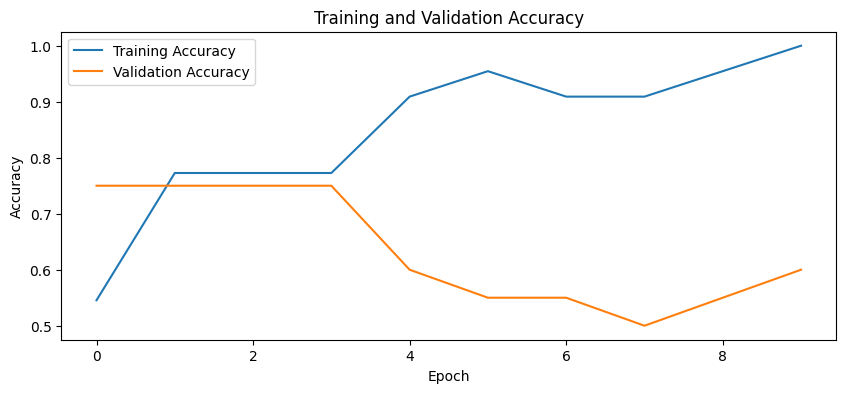

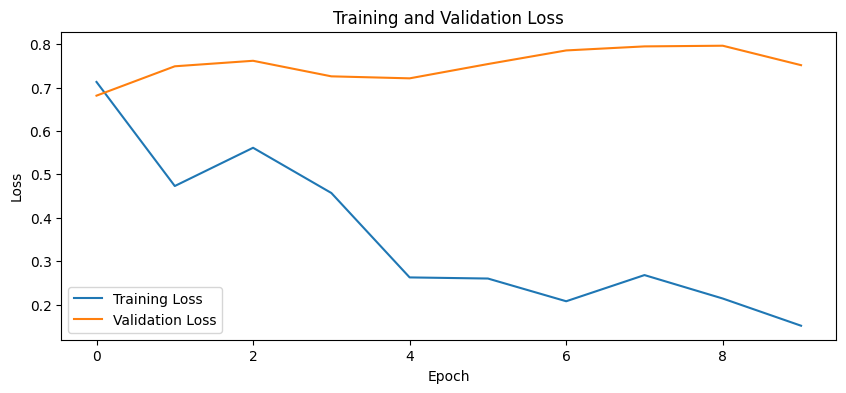

In [16]:
# Plot training & validation accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot training & validation loss
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.7619 - loss: 0.4447
Test Loss: 0.4447
Test Accuracy: 0.7619


In [18]:
# Save the full Keras model
model.save("skin_lesion_model.h5")
print("Keras model saved to 'skin_lesion_model.h5'")


Keras model saved to 'skin_lesion_model.h5'


In [19]:
# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open("skin_lesion_model.tflite", "wb") as f:
    f.write(tflite_model)
print("TFLite model saved to 'skin_lesion_model.tflite'")

# Create a quantized model for smaller size/faster inference
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_model = converter.convert()

# Save the quantized model
with open("skin_lesion_model_quant.tflite", "wb") as f:
    f.write(quantized_model)
print("Quantized TFLite model saved to 'skin_lesion_model_quant.tflite'")


INFO:tensorflow:Assets written to: C:\Users\LARINA~1\AppData\Local\Temp\tmpo05d5b7z\assets


INFO:tensorflow:Assets written to: C:\Users\LARINA~1\AppData\Local\Temp\tmpo05d5b7z\assets


Saved artifact at 'C:\Users\LARINA~1\AppData\Local\Temp\tmpo05d5b7z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_314')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2640996585488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996597008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996593360: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO:tensorflow:Assets written to: C:\Users\LARINA~1\AppData\Local\Temp\tmpoarhxpvk\assets


Saved artifact at 'C:\Users\LARINA~1\AppData\Local\Temp\tmpoarhxpvk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_314')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2640996585488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996597008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996594512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996595472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2640996593360: TensorSpec(shape=(), dtype=tf.resource, name=None)
